In [76]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [77]:
torch.manual_seed(42)

In [78]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hidden_size = 20

seq_len = 20
batch_size = 16

learning_rate = 0.001
epochs = 100

tot_seq_size = 10000

In [79]:
Human_Nouns = ['boy', 'girl', 'man', 'woman', 'child', 'teacher', 'student']
Animal_Nouns = ['dog', 'cat', 'bird', 'lion', 'mouse']
Food_Nouns = ['bread', 'apple', 'cookie', 'cake', 'fruit', 'milk', 'rice']
Object_Nouns = ['ball', 'book', 'toy']

Perception_Verbs = ['sees', 'watches']
Action_Verbs = ['chases', 'finds', 'helps', 'follows', 'meets']
Emotion_Verbs = ['likes', 'loves']
Eating_Verbs = ['eats']

Determiners= ["a", "the"]
Connectors= ["and","or"]
Adverbs= ["today", "slowly", "quickly"]
Prepositions= ["near", "with"]

In [80]:
import random

templates = [
    # 3 words: human/animal does action to object/animal
    lambda: [
        random.choice(Human_Nouns + Animal_Nouns),
        random.choice(Perception_Verbs + Action_Verbs + Emotion_Verbs),
        random.choice(Animal_Nouns + Object_Nouns + Food_Nouns)
    ],

    # 3 words: eating sentence
    lambda: [
        random.choice(Human_Nouns + Animal_Nouns),
        random.choice(Eating_Verbs),
        random.choice(Food_Nouns)
    ],

    # 5 words: determiner + noun + verb + determiner + object
    lambda: [
        random.choice(Determiners),
        random.choice(Human_Nouns + Animal_Nouns),
        random.choice(Perception_Verbs + Action_Verbs + Emotion_Verbs),
        random.choice(Determiners),
        random.choice(Animal_Nouns + Object_Nouns + Food_Nouns)
    ],

    # 5 words: noun and noun verb object
    lambda: [
        random.choice(Human_Nouns + Animal_Nouns),
        random.choice(Connectors),
        random.choice(Human_Nouns + Animal_Nouns),
        random.choice(Perception_Verbs + Action_Verbs + Emotion_Verbs),
        random.choice(Animal_Nouns + Object_Nouns + Food_Nouns)
    ],

    # 6 words: determiner + noun + verb + determiner + object + adverb
    lambda: [
        random.choice(Determiners),
        random.choice(Human_Nouns + Animal_Nouns),
        random.choice(Perception_Verbs + Action_Verbs + Emotion_Verbs),
        random.choice(Determiners),
        random.choice(Animal_Nouns + Object_Nouns + Food_Nouns),
        random.choice(Adverbs)
    ],

    # 8 words: determiner + noun + verb + determiner + object + prep + determiner + noun
    lambda: [
        random.choice(Determiners),
        random.choice(Human_Nouns + Animal_Nouns),
        random.choice(Perception_Verbs + Action_Verbs + Emotion_Verbs),
        random.choice(Determiners),
        random.choice(Animal_Nouns + Object_Nouns + Food_Nouns),
        random.choice(Prepositions),
        random.choice(Determiners),
        random.choice(Human_Nouns + Animal_Nouns + Object_Nouns)
    ]
]

In [81]:
seq=[]
for _ in range(tot_seq_size):
  words=random.choice(templates)()
  seq.extend(words)

In [82]:
print(seq[:50])
print(len(seq))

['girl', 'or', 'woman', 'loves', 'milk', 'a', 'teacher', 'chases', 'a', 'bread', 'near', 'a', 'lion', 'bird', 'follows', 'milk', 'the', 'man', 'meets', 'the', 'rice', 'bird', 'eats', 'cake', 'teacher', 'or', 'child', 'finds', 'apple', 'a', 'bird', 'loves', 'the', 'bread', 'slowly', 'a', 'bird', 'sees', 'the', 'cat', 'the', 'boy', 'sees', 'the', 'rice', 'with', 'the', 'teacher', 'a', 'student']
49966


In [83]:
input = seq[:-1]
target = seq[1:]

In [84]:
vocab=sorted(list(set(seq)))
# for i,j in enumerate(vocab):
#   print(i)
#   print(j)

In [85]:
# integer encoding
word_to_idx = {word: idx for idx,word in enumerate(vocab)}
idx_to_word = {idx: word for word,idx in word_to_idx.items()}

input = [word_to_idx[word] for word in input]
target = [word_to_idx[word] for word in target]

In [86]:
# 80% training and 20% testing
split_idx = int(0.8 * len(input))

train_input = input[:split_idx]
test_input = input[split_idx:]

train_target = target[:split_idx]
test_target = target[split_idx:]

In [87]:
vocab_size = len(word_to_idx)

num_features = vocab_size
output_size = vocab_size

In [88]:
print(seq[:20])
print(vocab)
print(input[:20])

['girl', 'or', 'woman', 'loves', 'milk', 'a', 'teacher', 'chases', 'a', 'bread', 'near', 'a', 'lion', 'bird', 'follows', 'milk', 'the', 'man', 'meets', 'the']
['a', 'and', 'apple', 'ball', 'bird', 'book', 'boy', 'bread', 'cake', 'cat', 'chases', 'child', 'cookie', 'dog', 'eats', 'finds', 'follows', 'fruit', 'girl', 'helps', 'likes', 'lion', 'loves', 'man', 'meets', 'milk', 'mouse', 'near', 'or', 'quickly', 'rice', 'sees', 'slowly', 'student', 'teacher', 'the', 'today', 'toy', 'watches', 'with', 'woman']
[18, 28, 40, 22, 25, 0, 34, 10, 0, 7, 27, 0, 21, 4, 16, 25, 35, 23, 24, 35]


In [89]:
#custom dataset class

class CustomDataset(Dataset):
  def __init__(self,input,target,seq_len):
    super().__init__()
    self.input=input
    self.target=target
    self.seq_len=seq_len

  def __len__(self):
    return len(self.input)-self.seq_len+1

  def __getitem__(self,sample):
    x=self.input[sample:sample+self.seq_len]
    y=self.target[sample:sample+self.seq_len]

    x=torch.tensor(x).long()
    y=torch.tensor(y).long()

    x=torch.nn.functional.one_hot(x, num_classes=vocab_size).float()

    # print(x.shape)
    # print(y.shape)

    return x,y

In [90]:
train_dataset=CustomDataset(train_input, train_target, seq_len=seq_len)
test_dataset=CustomDataset(test_input, test_target, seq_len=seq_len)

In [91]:
#create train and test loader
train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False,pin_memory=True)

In [92]:
#define nn
class RNNcell(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.inp_layer=nn.Linear(num_features,hidden_size)
    self.hidden_layer=nn.Linear(hidden_size,hidden_size)

  def forward(self,x_t,h_prev):
    inp_part=self.inp_layer(x_t)
    hidden_part=self.hidden_layer(h_prev)
    h_t=torch.tanh(inp_part+hidden_part)
    return h_t

In [93]:
# wrapper func
class RNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.rnncell=RNNcell(num_features)
    self.out_layer=nn.Linear(hidden_size,vocab_size)

  def forward(self,x,return_hidden=False):
    batch_size=x.shape[0]
    seq_len = x.shape[1]
    h0=torch.zeros(batch_size, hidden_size, device=x.device)

    hidden_states=[]
    outputs=[]
    for t in range(seq_len):
      x_t=x[:,t,:]   # [batchsize,6]
      h_t=self.rnncell(x_t,h0)
      out=self.out_layer(h_t)  # [batchsize,6]

      outputs.append(out)
      hidden_states.append(h_t)

      h0=h_t

    outputs = torch.stack(outputs, dim=1)
    hidden_states = torch.stack(hidden_states, dim=1)

    if return_hidden:
        return outputs, hidden_states


    return outputs

In [94]:
# create model
model=RNN(vocab_size)
model=model.to(device)

#loss func
criterion = nn.CrossEntropyLoss()

#define optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [95]:
#training loop
train_loss_history = []
final_epoch_loss=[]
for epoch in range(epochs):
    model.train()
    total_epoch_loss=0
    for batch_features, batch_labels in train_loader:

        #forward pass
        y_pred=model(batch_features)

        # print("y_pred shape:", y_pred.shape)
        # print("batch_labels shape:", batch_labels.shape)
        # break

        #loss
        loss = criterion(y_pred.reshape(-1,vocab_size),batch_labels.reshape(-1))

        #zero gradient
        optimizer.zero_grad()

        #backward pass
        loss.backward()

        #update params
        optimizer.step()

        #print loss
        total_epoch_loss+=loss.item()
        if epoch==epochs-1:
            final_epoch_loss.append(loss.item())
    avg_loss = total_epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)

    print(f"Epoch: {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch: 1/100, Loss: 2.4401
Epoch: 2/100, Loss: 2.2150
Epoch: 3/100, Loss: 2.2039
Epoch: 4/100, Loss: 2.1991
Epoch: 5/100, Loss: 2.1964
Epoch: 6/100, Loss: 2.1943
Epoch: 7/100, Loss: 2.1926
Epoch: 8/100, Loss: 2.1913
Epoch: 9/100, Loss: 2.1900
Epoch: 10/100, Loss: 2.1888
Epoch: 11/100, Loss: 2.1878
Epoch: 12/100, Loss: 2.1870
Epoch: 13/100, Loss: 2.1862
Epoch: 14/100, Loss: 2.1853
Epoch: 15/100, Loss: 2.1846
Epoch: 16/100, Loss: 2.1841
Epoch: 17/100, Loss: 2.1834
Epoch: 18/100, Loss: 2.1828
Epoch: 19/100, Loss: 2.1822
Epoch: 20/100, Loss: 2.1816
Epoch: 21/100, Loss: 2.1812
Epoch: 22/100, Loss: 2.1806
Epoch: 23/100, Loss: 2.1801
Epoch: 24/100, Loss: 2.1797
Epoch: 25/100, Loss: 2.1794
Epoch: 26/100, Loss: 2.1790
Epoch: 27/100, Loss: 2.1785
Epoch: 28/100, Loss: 2.1780
Epoch: 29/100, Loss: 2.1778
Epoch: 30/100, Loss: 2.1774
Epoch: 31/100, Loss: 2.1772
Epoch: 32/100, Loss: 2.1769
Epoch: 33/100, Loss: 2.1765
Epoch: 34/100, Loss: 2.1763
Epoch: 35/100, Loss: 2.1761
Epoch: 36/100, Loss: 2.1759
E

In [96]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        y_pred = model(batch_features)

        predicted = torch.argmax(y_pred, dim=-1)

        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.numel()

accuracy = correct / total * 100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 20.24%


In [97]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        y_pred = model(batch_features)

        predicted = torch.argmax(y_pred, dim=-1)

        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.numel()

accuracy = correct / total * 100

print(f"Train Accuracy: {accuracy:.2f}%")

Train Accuracy: 22.60%


In [98]:
model.eval()

with torch.no_grad():
    X, y = next(iter(test_loader))

    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    predicted = torch.argmax(y_pred, dim=-1)

# first sample only
true_indices = y[0].cpu().tolist()
pred_indices = predicted[0].cpu().tolist()

true_letters = [idx_to_word[i] for i in true_indices]
pred_letters = [idx_to_word[i] for i in pred_indices]

print("True:")
print(true_letters)

print("\nPredicted:")
print(pred_letters)

True:
['man', 'likes', 'bread', 'a', 'student', 'finds', 'the', 'apple', 'the', 'student', 'helps', 'a', 'cake', 'dog', 'eats', 'rice', 'a', 'woman', 'likes', 'the']

Predicted:
['a', 'eats', 'fruit', 'the', 'mouse', 'chases', 'a', 'cat', 'with', 'cat', 'chases', 'the', 'cat', 'with', 'eats', 'fruit', 'the', 'student', 'chases', 'a']


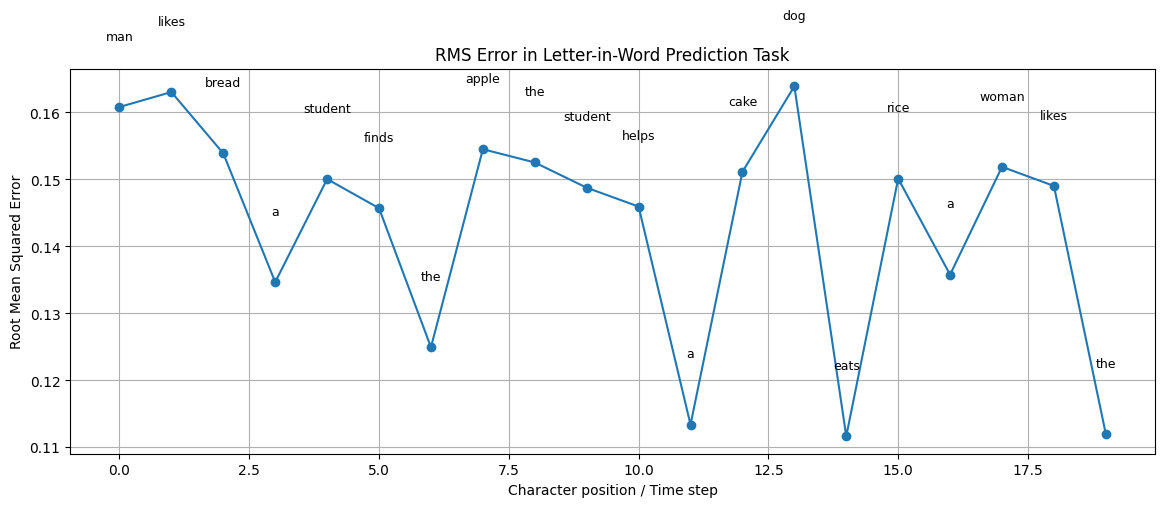

In [99]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():

    X, y = next(iter(test_loader))

    X = X.to(device)
    y = y.to(device)

    # model prediction
    logits = model(X)                         # [batch, seq_len, vocab_size]

    # convert logits to probabilities
    probs = torch.softmax(logits, dim=-1)     # [batch, seq_len, vocab_size]

    # convert true labels to one-hot vectors
    y_onehot = F.one_hot(
        y,
        num_classes=vocab_size
    ).float()                                 # [batch, seq_len, vocab_size]

    # RMS error over full output vector
    rms_error = torch.sqrt(
        torch.mean((probs - y_onehot) ** 2, dim=-1)
    )                                        # [batch, seq_len]

    # take first sample from batch
    errors = rms_error[0].cpu().numpy()
    labels = y[0].cpu().tolist()

# convert label indices back to characters
chars = [idx_to_word[i] for i in labels]

plt.figure(figsize=(14,5))

plt.plot(errors, marker='o')

for i, char in enumerate(chars):
    plt.text(
        i,
        errors[i] + 0.01,
        char,
        ha='center',
        fontsize=9
    )

plt.xlabel("Character position / Time step")
plt.ylabel("Root Mean Squared Error")
plt.title("RMS Error in Letter-in-Word Prediction Task")

plt.grid()
plt.show()

In [105]:
from collections import defaultdict
import torch
import numpy as np

model.eval()

word_hidden_states = defaultdict(list)

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # outputs: [batch, seq_len, vocab_size]
        # hidden:  [batch, seq_len, hidden_size]
        outputs, hidden = model(batch_features, return_hidden=True)

        batch_size_current = batch_labels.shape[0]
        seq_len_current = batch_labels.shape[1]

        for b in range(batch_size_current):
            for t in range(seq_len_current):

                word_idx = batch_labels[b, t].item()
                word = idx_to_word[word_idx]

                h_t = hidden[b, t].detach().cpu().numpy()

                word_hidden_states[word].append(h_t)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [106]:
word_vectors = {}
words = []

for word, states in word_hidden_states.items():

    avg_state = np.mean(states, axis=0)

    word_vectors[word] = avg_state
    words.append(word)

X_hidden = np.array([word_vectors[word] for word in words])

print("Number of words:", len(words))
print("Hidden vector shape:", X_hidden.shape)

Number of words: 41
Hidden vector shape: (41, 20)


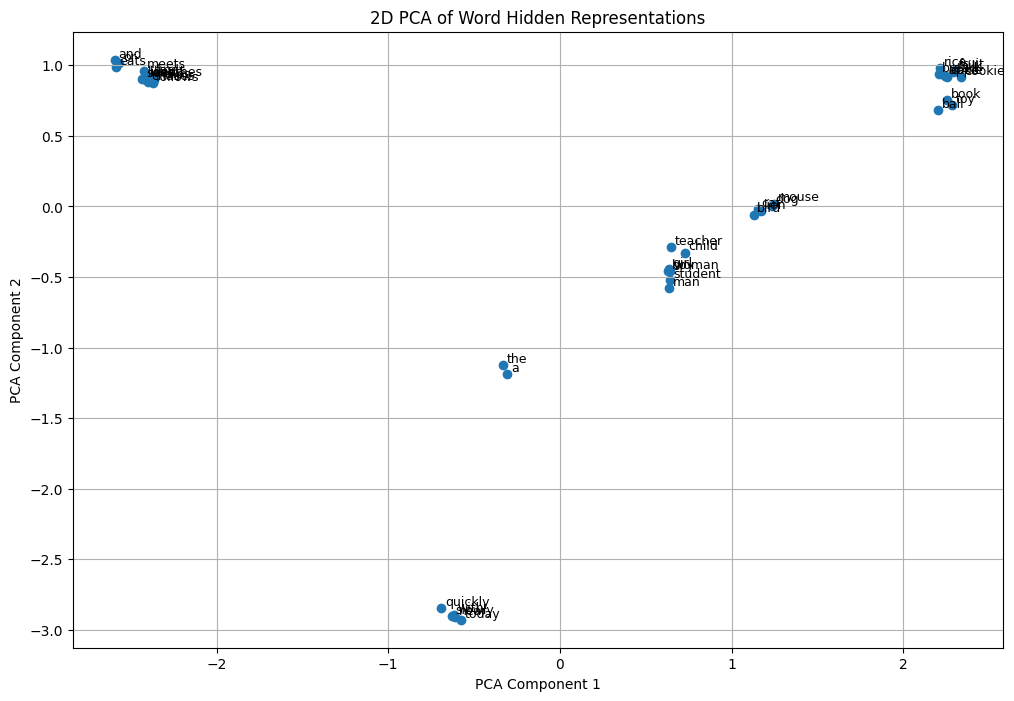

In [107]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_2d = pca.fit_transform(X_hidden)

plt.figure(figsize=(12, 8))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1]
)

for i, word in enumerate(words):
    plt.text(
        X_2d[i, 0] + 0.02,
        X_2d[i, 1] + 0.02,
        word,
        fontsize=9
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D PCA of Word Hidden Representations")
plt.grid()
plt.show()

In [108]:
def get_category(word):
    if word in Human_Nouns:
        return "Human"
    elif word in Animal_Nouns:
        return "Animal"
    elif word in Food_Nouns:
        return "Food"
    elif word in Object_Nouns:
        return "Object"
    elif word in Perception_Verbs:
        return "Perception Verb"
    elif word in Action_Verbs:
        return "Action Verb"
    elif word in Emotion_Verbs:
        return "Emotion Verb"
    elif word in Eating_Verbs:
        return "Eating Verb"
    elif word in Determiners:
        return "Determiner"
    elif word in Connectors:
        return "Connector"
    elif word in Adverbs:
        return "Adverb"
    elif word in Prepositions:
        return "Preposition"
    else:
        return "Other"

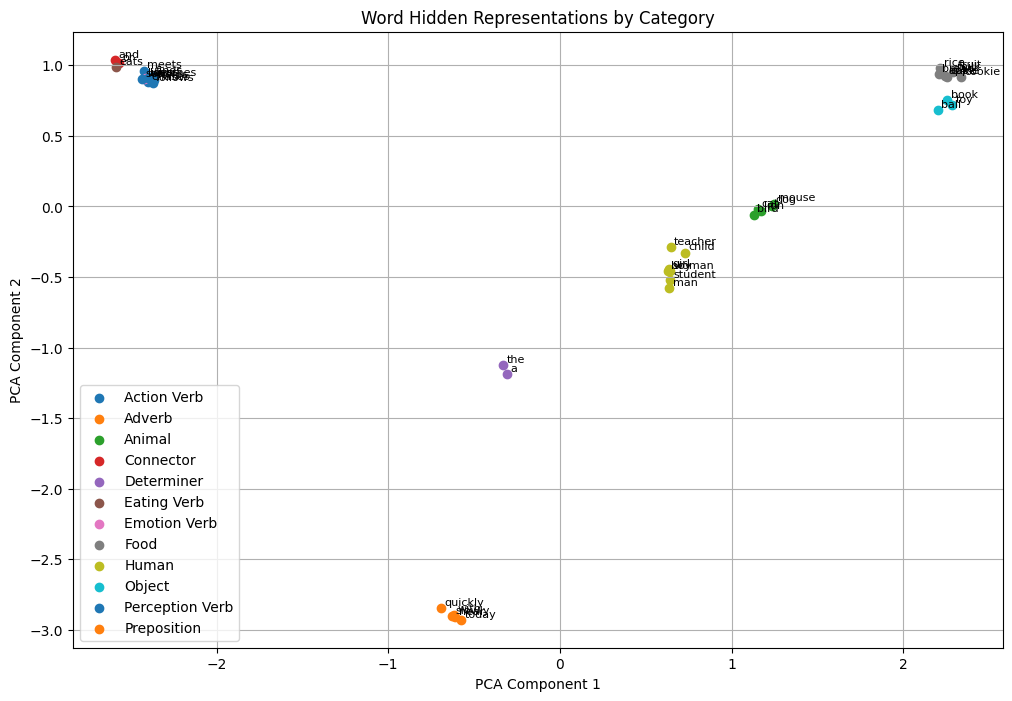

In [109]:
categories = [get_category(word) for word in words]
unique_categories = sorted(list(set(categories)))

plt.figure(figsize=(12, 8))

for category in unique_categories:

    idxs = [i for i, c in enumerate(categories) if c == category]

    plt.scatter(
        X_2d[idxs, 0],
        X_2d[idxs, 1],
        label=category
    )

    for i in idxs:
        plt.text(
            X_2d[i, 0] + 0.02,
            X_2d[i, 1] + 0.02,
            words[i],
            fontsize=8
        )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Word Hidden Representations by Category")
plt.legend()
plt.grid()
plt.show()

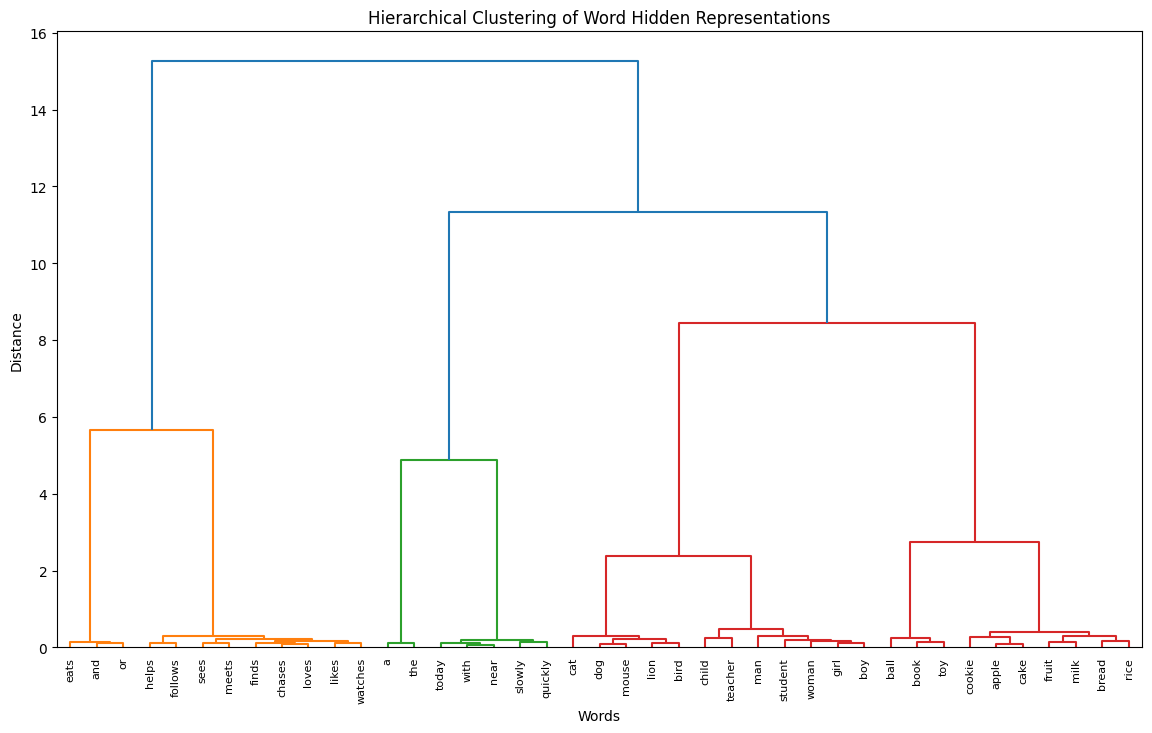

In [110]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(X_hidden, method="ward")

plt.figure(figsize=(14, 8))

dendrogram(
    linked,
    labels=words,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Word Hidden Representations")
plt.xlabel("Words")
plt.ylabel("Distance")

plt.show()